<a href="https://colab.research.google.com/github/hamshini1413/deep-learning/blob/main/3_Vectorized_Convolutional_Forward_Pass_via_im2col_Transformation_from_Scratch_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
# Input Image Parameters

batch_size = 2
in_channels = 3
height = 8
width = 8

# Random Input Tensor

X = np.random.randn(batch_size, in_channels, height, width)

print("Input Shape :", X.shape)

Input Shape : (2, 3, 8, 8)


In [3]:
# Convolution Parameters

out_channels = 4
kernel_size = 3
stride = 1
padding = 1

# Filters

W = np.random.randn(
    out_channels,
    in_channels,
    kernel_size,
    kernel_size
)

# Bias

b = np.random.randn(out_channels)

print("Kernel Shape :", W.shape)

Kernel Shape : (4, 3, 3, 3)


In [4]:
def im2col(images, kernel_size, stride, padding):

    N,C,H,W = images.shape

    H_padded = H + 2*padding
    W_padded = W + 2*padding

    padded = np.pad(
        images,
        ((0,0),(0,0),(padding,padding),(padding,padding)),
        mode='constant'
    )

    out_h = (H_padded-kernel_size)//stride + 1
    out_w = (W_padded-kernel_size)//stride + 1

    cols = []

    for y in range(out_h):

        for x in range(out_w):

            patch = padded[
                :,
                :,
                y*stride:y*stride+kernel_size,
                x*stride:x*stride+kernel_size
            ]

            cols.append(
                patch.reshape(N,-1)
            )

    cols = np.array(cols)

    cols = cols.transpose(1,2,0)

    return cols,out_h,out_w

In [5]:
def convolution_forward(X,W,b,stride,padding):

    kernel = W.shape[2]

    cols,out_h,out_w = im2col(
        X,
        kernel,
        stride,
        padding
    )

    W_col = W.reshape(W.shape[0],-1)

    output = np.zeros(
        (
            X.shape[0],
            W.shape[0],
            out_h*out_w
        )
    )

    for n in range(X.shape[0]):

        output[n] = np.dot(
            W_col,
            cols[n]
        ) + b.reshape(-1,1)

    output = output.reshape(
        X.shape[0],
        W.shape[0],
        out_h,
        out_w
    )

    return output

In [6]:
output = convolution_forward(
    X,
    W,
    b,
    stride,
    padding
)

print("Output Shape :", output.shape)

Output Shape : (2, 4, 8, 8)


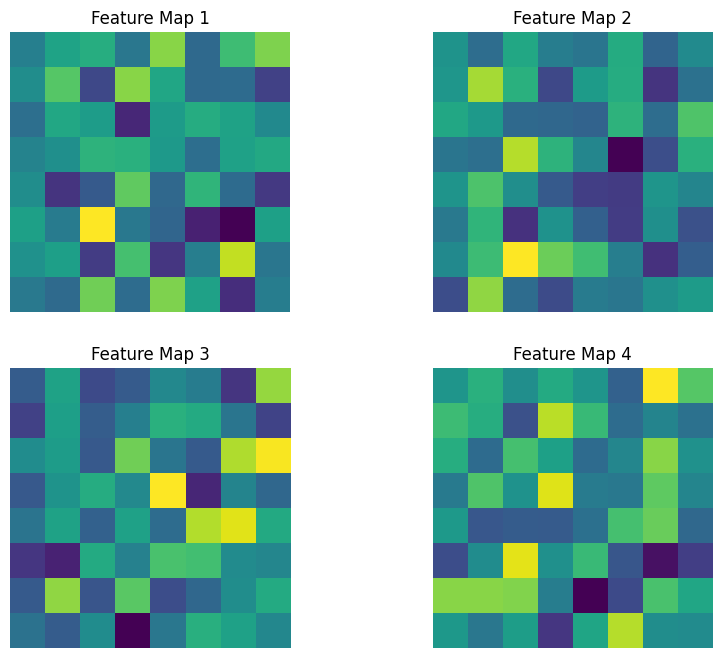

In [7]:
plt.figure(figsize=(10,8))

for i in range(4):

    plt.subplot(2,2,i+1)

    plt.imshow(
        output[0,i],
        cmap="viridis"
    )

    plt.title(f"Feature Map {i+1}")

    plt.axis("off")

plt.show()

In [8]:
print("----------- Summary -----------")

print("Input Shape :",X.shape)

print("Kernel Shape :",W.shape)

print("Stride :",stride)

print("Padding :",padding)

print("Output Shape :",output.shape)

----------- Summary -----------
Input Shape : (2, 3, 8, 8)
Kernel Shape : (4, 3, 3, 3)
Stride : 1
Padding : 1
Output Shape : (2, 4, 8, 8)
